In [99]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

import matplotlib.pyplot as plt

In [100]:
df = pd.read_csv('Nazarov.csv')

In [101]:
print(df.head())
print(f"\nРазмер: {df.shape}")
print(f"Колонки: {df.columns[:10].tolist()}...")

  Email No.  the  to  ect  and  for  of    a  you  hou  ...  connevey  jay  \
0   Email 1    0   0    1    0    0   0    2    0    0  ...         0    0   
1   Email 2    8  13   24    6    6   2  102    1   27  ...         0    0   
2   Email 3    0   0    1    0    0   0    8    0    0  ...         0    0   
3   Email 4    0   5   22    0    5   1   51    2   10  ...         0    0   
4   Email 5    7   6   17    1    5   2   57    0    9  ...         0    0   

   valued  lay  infrastructure  military  allowing  ff  dry  Prediction  
0       0    0               0         0         0   0    0           0  
1       0    0               0         0         0   1    0           0  
2       0    0               0         0         0   0    0           0  
3       0    0               0         0         0   0    0           0  
4       0    0               0         0         0   1    0           0  

[5 rows x 3002 columns]

Размер: (5172, 3002)
Колонки: ['Email No.', 'the', 'to', 'ect

In [102]:
y = df['Prediction'].values
X = df.drop(columns=['Prediction']).values

In [103]:
if df.columns[0] == 'Email No.':
    X = df.drop(columns=['Email No.', 'Prediction']).values

In [104]:
print(f"Размер X: {X.shape}")
print(f"Размер y: {y.shape}")
print(f"Уникальные классы: {np.unique(y)}")

Размер X: (5172, 3000)
Размер y: (5172,)
Уникальные классы: [0 1]


In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [106]:
print(f"Обучающая выборка: {X_train.shape}")
print(f"Тестовая выборка: {X_test.shape}")

Обучающая выборка: (4137, 3000)
Тестовая выборка: (1035, 3000)


In [107]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [108]:
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

C:\Users\rnaza\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [109]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                │ (None, 128)            │       384,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 394,497 (1.50 MB)

 Trainable params: 394,497 (1.50 MB)

 Non-trainable params: 0 (0.00 B)

In [110]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

In [111]:
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8338 - loss: 0.3747 - val_accuracy: 0.9734 - val_loss: 0.0968
Epoch 2/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9677 - loss: 0.0864 - val_accuracy: 0.9674 - val_loss: 0.0922
Epoch 3/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9864 - loss: 0.0442 - val_accuracy: 0.9650 - val_loss: 0.0857
Epoch 4/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9831 - loss: 0.0434 - val_accuracy: 0.9686 - val_loss: 0.0876
Epoch 5/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9921 - loss: 0.0223 - val_accuracy: 0.9734 - val_loss: 0.1052
Epoch 6/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9930 - loss: 0.0227 - val_accuracy: 0.9795 - val_loss: 0.1348
Epoch 7/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9930 - loss: 0.0185 - val_accuracy: 0.9795 - val_loss: 0.1246
Epoch 8/50
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9934 - loss: 0.0173 - val_accuracy: 0.

In [112]:
plt.figure(figsize=(12, 4))

<Figure size 1200x400 with 0 Axes>

<Figure size 1200x400 with 0 Axes>

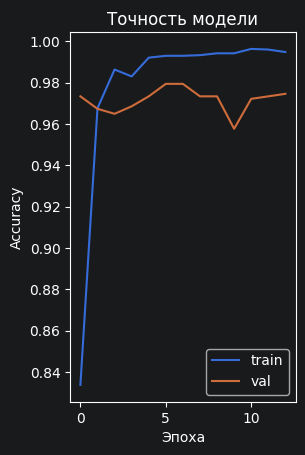

In [113]:
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='val')
plt.title('Точность модели')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()

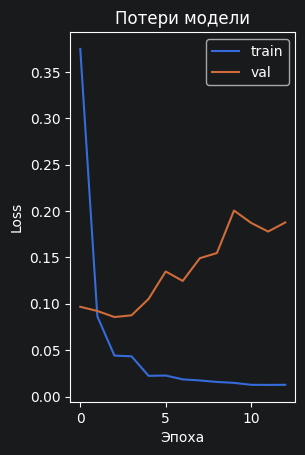

In [114]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.title('Потери модели')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()

In [115]:
plt.tight_layout()
plt.show()

<Figure size 640x480 with 0 Axes>

In [116]:
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

33/33 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [117]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Точность на тестовой выборке: {accuracy:.4f}")

Точность на тестовой выборке: 0.9778


In [118]:
test_sample = X_test[0].reshape(1, -1)
true_label = y_test[0]

In [119]:
pred = model.predict(test_sample, verbose=0)[0][0]
pred_label = 1 if pred > 0.5 else 0

In [120]:
print(f"Реальный класс: {true_label} ({'Работа' if true_label==1 else 'Личное'})")
print(f"Предсказанный класс: {pred_label} ({'Работа' if pred_label==1 else 'Личное'})")
print(f"Вероятность: {pred:.4f}")

Реальный класс: 0 (Личное)
Предсказанный класс: 0 (Личное)
Вероятность: 0.0013


In [121]:
model.save('email_classifier.keras')

In [122]:
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']